In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d

In [3]:
cancer = pd.read_csv('dataset/wdbc.csv')
# print(cancer.head())
cancer 

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
# take a closer look at the data
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
# investigate  a diagnosis column and return the number of unique values
cancer['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [6]:
#clean diagnsis data values M = 1, B = 0

cancer['diagnosis'] = cancer['diagnosis'].map({'M': "Melignant", 'B': 'Benign'})


cancer['diagnosis'].unique()



array(['Melignant', 'Benign'], dtype=object)

In [8]:
#see distribution of diagnosis
cancer['diagnosis'].value_counts()
cancer['diagnosis'].value_counts(normalize=True)

diagnosis
Benign       0.627417
Melignant    0.372583
Name: proportion, dtype: float64

In [9]:
cancer.groupby('diagnosis').size()
(cancer.groupby('diagnosis').size() / cancer.shape[0]) * 100

diagnosis
Benign       62.741652
Melignant    37.258348
dtype: float64

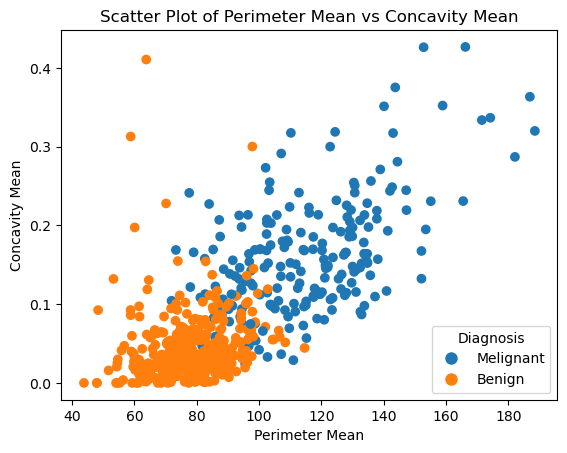

In [10]:
# Create mapping between values and colors
labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Plot
plt.scatter(cancer["perimeter_mean"], cancer['concavity_mean'], 
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles, title='Diagnosis')
plt.show()

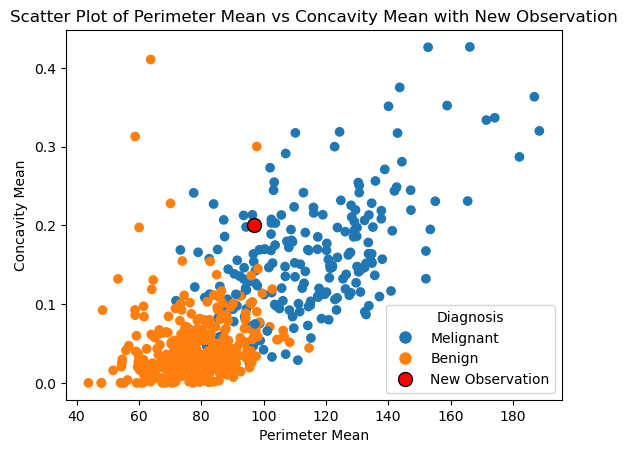

In [11]:
# Plot existing data
plt.scatter(cancer["perimeter_mean"], cancer['concavity_mean'], 
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add new observation
new_observation = {'perimeter_mean': 97, 'concavity_mean': 0.20}
plt.scatter(new_observation['perimeter_mean'], new_observation['concavity_mean'],
            color='red', edgecolor='black', s=100, label='New Observation')

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean with New Observation')
plt.legend(handles=handles + [plt.Line2D([0], [0], marker='o', color='w', label='New Observation',
                                         markersize=10, markerfacecolor='red', markeredgecolor='black')],
           title='Diagnosis')
plt.show()

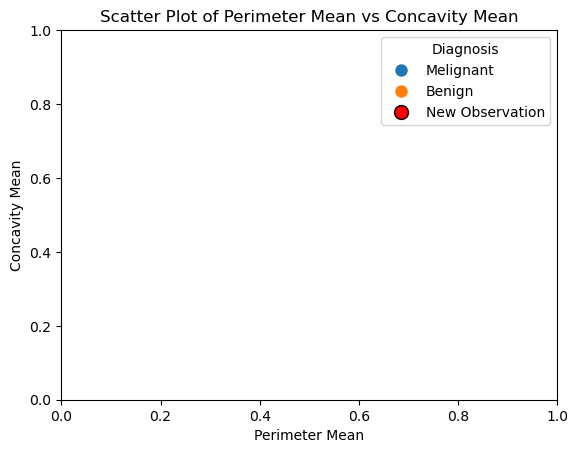

In [12]:
# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles + [plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor='red', markeredgecolor='black', 
                                         markersize=10, label='New Observation')],
           title='Diagnosis')
plt.show()

In [14]:
new_obs_Perimeter = new_observation['perimeter_mean']
new_obs_Concavity = new_observation['concavity_mean']

cancer['dist_from_new'] = (
    (cancer['perimeter_mean'] - new_obs_Perimeter)**2 +
    (cancer['concavity_mean'] - new_obs_Concavity)**2
) ** 0.5

cancer['dist_from_new']

0      25.800194
1      35.900178
2      33.000000
3      19.420044
4      38.100000
         ...    
564    45.000021
565    34.200046
566    11.300511
567    43.100266
568    49.080407
Name: dist_from_new, Length: 569, dtype: float64

In [16]:
# Sort by distance from new observation
cancer.sort_values('dist_from_new')



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,dist_from_new
291,8915,Benign,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.04819,...,26.19,109.1,809.8,0.1313,0.3030,0.1804,0.1489,0.2962,0.08472,0.143765
138,868826,Melignant,14.95,17.57,96.85,678.1,0.11670,0.13050,0.15390,0.08624,...,21.43,121.4,971.4,0.1411,0.2164,0.3355,0.1667,0.3414,0.07147,0.156924
15,84799002,Melignant,14.54,27.54,96.73,658.8,0.11390,0.15950,0.16390,0.07364,...,37.13,124.1,943.2,0.1678,0.6577,0.7026,0.1712,0.4218,0.13410,0.272403
514,91594602,Melignant,15.05,19.07,97.26,701.9,0.09215,0.08597,0.07486,0.04335,...,28.06,113.8,967.0,0.1246,0.2101,0.2866,0.1120,0.2282,0.06954,0.288548
54,857438,Melignant,15.10,22.02,97.26,712.8,0.09056,0.07081,0.05253,0.03334,...,31.69,117.7,1030.0,0.1389,0.2057,0.2712,0.1530,0.2675,0.07873,0.298910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,8611555,Melignant,25.22,24.91,171.50,1878.0,0.10630,0.26650,0.33390,0.18450,...,33.62,211.7,2562.0,0.1573,0.6076,0.6476,0.2867,0.2355,0.10510,74.500120
352,899987,Melignant,25.73,17.46,174.20,2010.0,0.11490,0.23630,0.33680,0.19130,...,23.58,229.3,3234.0,0.1530,0.5937,0.6451,0.2756,0.3690,0.08815,77.200121
180,873592,Melignant,27.22,21.87,182.10,2250.0,0.10940,0.19140,0.28710,0.18780,...,32.85,220.8,3216.0,0.1472,0.4034,0.5340,0.2688,0.2856,0.08082,85.100045
461,911296202,Melignant,27.42,26.27,186.90,2501.0,0.10840,0.19880,0.36350,0.16890,...,31.37,251.2,4254.0,0.1357,0.4256,0.6833,0.2625,0.2641,0.07427,89.900149


In [26]:
nearest_5 = cancer.nsmallest(5, 'dist_from_new')[[
    'perimeter_mean',
    'concavity_mean', 
    'diagnosis', 
    'dist_from_new'
]]

nearest_5
                                                 

,perimeter_mean,concavity_mean,diagnosis,dist_from_new
291,97.03,0.05940,Benign,0.143765
138,96.85,0.15390,Melignant,0.156924
15,96.73,0.16390,Melignant,0.272403
514,97.26,0.07486,Melignant,0.288548
54,97.26,0.05253,Melignant,0.298910


In [27]:
from sklearn import set_config
set_config(transform_output='pandas')

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [69]:
cancer_train = cancer[['diagnosis', 'perimeter_mean', 'concavity_mean']]

cancer_train

,diagnosis,perimeter_mean,concavity_mean
0,Melignant,122.80,0.30010
1,Melignant,132.90,0.08690
2,Melignant,130.00,0.19740
3,Melignant,77.58,0.24140
4,Melignant,135.10,0.19800
...,...,...,...
564,Melignant,142.00,0.24390
565,Melignant,131.20,0.14400
566,Melignant,108.30,0.09251
567,Melignant,140.10,0.35140


In [82]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

In [83]:
# define our predictor variables
X = cancer_train[['perimeter_mean', 'concavity_mean']]
y = cancer_train['diagnosis']



In [84]:
#fit our model
knn.fit(X, y)

KNeighborsClassifier()

In [85]:
#new observation
new_obs = pd.DataFrame({"perimeter_mean":97, "concavity_mean":[0.2]})
new_obs

,perimeter_mean,concavity_mean
0,97,0.2


In [86]:
#find the 5 nearest neighbors
knn.predict(new_obs)

array(['Melignant'], dtype=object)